In [1]:
from __future__ import division

import numpy as np
import glob
import matplotlib.pyplot as plt
import scipy.linalg as sl
import json
import pint
import sys
import corner
import shutil
import os

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

import pta_replicator
from pta_replicator.white_noise import add_measurement_noise
from pta_replicator.white_noise import add_jitter
from pta_replicator.red_noise import add_red_noise, add_gwb
from pta_replicator.simulate import load_pulsar, load_from_directories, simulate_pulsar
from pta_replicator.simulate import make_ideal

pint.logging.setup(sink=sys.stderr,level="WARNING",usecolors=True)

libstempo not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


1

In [33]:
from pathlib import Path

viperdir = '/Users/dalloncarlson/Documents/WFU/VIPER_Mini_Project/VIPER-2026/VIPER-2026'
pardir = viperdir + '/data/NG15/par'
timdir = viperdir + '/data/NG15/tim'
noisedictdir = viperdir + '/ng15_dict_2.json'
parfiles = sorted(glob.glob(viperdir + '/data/NG15/par/*.par'))
timfiles = sorted(glob.glob(viperdir + '/data/NG15/tim/*.tim'))
outDir = '/Users/dalloncarlson/Documents/WFU/VIPER_Mini_Project/VIPER-2026/VIPER-2026/saved/results/chain'
sim_tim_dir = './simulated_tims'

print(sim_tim_dir)

num_psrs = 8
N = int(500000)

shutil.rmtree('./simulated_tims', ignore_errors=True)
shutil.rmtree(outDir, ignore_errors=True)  # or outDir, whichever you're using


./simulated_tims


# pta_replicator

In [ ]:
psrs = load_from_directories(pardir, timdir, num_psrs=num_psrs)
print(psrs)

with open(noisedictdir, 'r') as fp:
    noise_params = json.load(fp)

# change number strings to floats:
for value in noise_params.values():
    value = float(value)

In [ ]:
psrlist = [psr.name for psr in psrs]
noise_dict = {}

for p in psrlist:
    noise_dict[p] = {}
    noise_dict[p]['log10_equads'] = []
    noise_dict[p]['efacs'] = []
    noise_dict[p]['log10_ecorrs'] = []
    for ky in list(noise_params.keys()):
        if p in ky:
            if 'equad' in ky:
                noise_dict[p]['log10_equads'].append([ky.replace(p + '_' , '').replace('_log10_t2equad', ''), noise_params[ky]])
            if 'efac' in ky:
                noise_dict[p]['efacs'].append([ky.replace(p + '_' , '').replace('_efac', ''), noise_params[ky]])
            if 'ecorr' in ky:
                noise_dict[p]['log10_ecorrs'].append([ky.replace(p + '_' , '').replace('_log10_ecorr', ''), noise_params[ky]])
            if 'gamma' in ky:
                noise_dict[p]['rn_gamma'] = noise_params[ky]
            if 'log10_A' in ky:
                noise_dict[p]['rn_log10_amp'] = noise_params[ky]
                
    noise_dict[p]['log10_equads'] = np.array(noise_dict[p]['log10_equads'])
    noise_dict[p]['efacs'] = np.array(noise_dict[p]['efacs'])
    noise_dict[p]['log10_ecorrs'] = np.array(noise_dict[p]['log10_ecorrs'])

# print(noise_dict)

## By using seeds we can reproduce the dataset if need be. 
seed_efac_equad = 106032
seed_jitter = 17763232
seed_red = 19870132
seed_gwb = 15672232

In [ ]:
for ii, psr in enumerate(psrs):

    ## make ideal
    make_ideal(psr)

    ## add efacs
    # if you use flags, the flags and efac and equad values all need to have the same number of elements
    add_measurement_noise(psr, efac = noise_dict[psr.name]['efacs'][:,1].astype(float),
                          log10_equad = noise_dict[psr.name]['log10_equads'][:,1].astype(float), 
                          flagid = 'f', flags = noise_dict[psr.name]['efacs'][:,0], 
                          seed = seed_efac_equad + ii)

    ## add jitter
    add_jitter(psr, log10_ecorr = noise_dict[psr.name]['log10_ecorrs'][:,1].astype(float), 
                flagid='f', flags = noise_dict[psr.name]['log10_ecorrs'][:,0], 
                coarsegrain = 1.0/86400.0, seed = seed_jitter + ii)

    ## add red noise
    add_red_noise(psr,
                  log10_amplitude = noise_dict[psr.name]['rn_log10_amp'],
                  spectral_index = noise_dict[psr.name]['rn_gamma'],
                  components = 30, seed = seed_red + ii)

    print(ii, psr.name)

In [ ]:
add_gwb(psrs, log10_amplitude = -15, spectral_index = 13./3., seed = seed_gwb)

for psr in psrs:
    print(psr.added_signals)

In [ ]:
# for psr in psrs:
#     plt.errorbar(psr.toas.get_mjds(), psr.residuals.time_resids.to_value("us"),
#                  psr.residuals.get_data_error().to_value("us"), marker="+", ls="", label="Total")
#     for sig in psr.added_signals_time:
#         plt.plot(psr.toas.get_mjds(), psr.added_signals_time[sig].to_value("us"),
#                  marker='x', label=sig, ls="", zorder=5, alpha=0.5)

#     plt.legend()
#     plt.xlabel("MJD")
#     plt.ylabel("Residuals (us)")
#     plt.show()
#     plt.clf()



In [ ]:
from tqdm import tqdm

for psr in psrs:
    # Init plot
    fig, ax = plt.subplots(layout="constrained", figsize=(12, 4))

    # Names of added signals
    sig_meas = f"{psr.name}_measurement_noise"
    sig_jitter = f"{psr.name}_jitter"
    sig_red = f"{psr.name}_red_noise"
    sig_gwb = f"{psr.name}_gwb"

    # Horizontal line at 0
    plt.axhline(y=0, ls="--", color="gray")

    # Plot the data
    plt.errorbar(psr.toas.get_mjds(), psr.residuals.time_resids.to_value("us"),
                 psr.residuals.get_data_error().to_value("us"), c='black', marker="+", ls="", label="Total")

    # Plot individual signals
    for sig in psr.added_signals_time:
        plt.plot(psr.toas.get_mjds(), psr.added_signals_time[sig].to_value("us"),
                 marker='x', label=sig, ls="", zorder=5, alpha=0.5)

    # Add a legend
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.9, box.height])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("MJD")
    plt.ylabel(r"Residuals ($\mu s$)")
    plt.title(f"{psr.name} Simulated Residuals (A={-15.:.1f}, " + r"$\gamma$=" + r"$\frac{13}{3}$" + ")")
    plt.savefig("/Users/dalloncarlson/Documents/WFU/VIPER_Mini_Project/VIPER-2026/VIPER-2026/saved/plots/" + f"{psr.name}.png")
    plt.clf()
    plt.close()

# Nimas Code: pta_replicator

In [ ]:
os.makedirs(sim_tim_dir, exist_ok=True)

ent_psrs = []

# each simulated pulsar from the psrs list is saved to a .tim file and then loaded into an enterprise Pulsar object
for psr in psrs:
    sim_tim_path = os.path.join(sim_tim_dir, f"{psr.name}_sim.tim")
    psr.toas.write_TOA_file(sim_tim_path)
    
    par_file = [p for p in parfiles if psr.name in p][0]
    
    print(f"Loading {psr.name} into enterprise...")
    ent_psr = Pulsar(par_file, sim_tim_path, ephem='DE440')
    ent_psrs.append(ent_psr)

noise_dict = {}
for pname in [psr.name for psr in psrs]:
    noise_dict.update({pname + '_efac': 1.0})
    noise_dict.update({pname + '_log10_t2equad': -np.inf})

In [ ]:
from enterprise_extensions import blocks

pulsartime = []

Tspan = np.max([p.toas.max() for p in ent_psrs]) - np.min([p.toas.min() for p in ent_psrs])

tm = gp_signals.MarginalizingTimingModel(use_svd=True)

wn = blocks.white_noise_block(
    vary=False,
    inc_ecorr=False,
    gp_ecorr=False,
    select='none',
    tnequad=False,
)

gwb = blocks.common_red_noise_block(
    psd="powerlaw",
    prior="log-uniform",
    Tspan=Tspan,
    components=40,
    gamma_val=None,
    name="gw",
    orf="crn",
)

s = wn + gwb + tm

pta = signal_base.PTA(
    [s(p) for p in ent_psrs], signal_base.LogLikelihoodDenseCholesky
)
pta.set_default_params(noise_dict)
pta.param_names

In [ ]:
x0 = np.hstack([p.sample() for p in pta.params])
ndim = len(x0)

cov = np.diag(np.ones(ndim) * 0.01**2)


# set the location to save the output chains
sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, 
                 outDir=outDir, resume=False)

sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50, )

In [ ]:
chain = np.loadtxt(outDir + '/chain_1.txt')[:, :-4]
burn = int(0.25 * chain.shape[0])
chain = chain[burn:, :]
chain.shape

In [ ]:
# def figsize(scale, wc = 3, hc = 3):
#     fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
#     inches_per_pt = 1.0/72.27                       # Convert pt to inch
#     golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
#     fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
#     fig_height = fig_width*golden_mean              # height in inches
#     fig_size = [wc * fig_width,hc * fig_height]
#     return fig_size

# def make_corner(chains, 
#                 colors, 
#                 labels = None, 
#                 ranges = None,
#                 truths = None,
#                 save_path = None):
    
#     levels = [1 - np.exp(-0.5), 1 - np.exp(-1.0), 1 - np.exp(-1.5)]

#     s = int((chains[0].shape[-1])/2)
#     plt.close()
#     fig = plt.figure(figsize = figsize(0.5, s, s))
#     for chain, color in zip(chains, colors):
#         fig = corner.corner(
#         chain,
#         fig=fig,
#         range = ranges,
#         labels=labels,
#         color=color,
#         bins=20,
#         hist_bin_factor=2,
#         truths = truths,
#         truth_color = 'red',
#         data_kwargs={'ms': 3},
#         hist_kwargs={'density': True, 'lw': 2},
#         contour_kwargs={'linewidths': 2},
#         density=True,
#         plot_datapoints=False,
#         show_titles = True,
#         levels = levels
#     )


#     if save_path:
#         plt.savefig(save_path, bbox_inches='tight')
#     plt.show()

# make_corner(chains = [np.array(chain)], 
                # colors = ['gold'], 
                # labels = None, 
                # ranges = None,
                # truths = [13/3, np.log10(1e-14)],
                # save_path = None)

In [ ]:
chain = np.loadtxt(outDir +'/chain_1.txt')
burn = int(0.25 * chain.shape[0])
samples = chain[:, :ndim]
plt.hist(chain[burn:,-5], 50, histtype='step', lw=2);

labels = pta.param_names

if labels[0] == 'gw_gamma':
    truths = [13./3., -15.0]
else:
    truths = [-15.0, 13./3.]

chain.shape

fig = plt.figure(figsize=(6, 6), dpi=300)

figure = corner.corner(
    samples,
    plot_datapoints=False,
    truths=truths,
    labels=labels,
    truth_color='red',
    bins=40,
    smooth=1.0,
    plot_density=True,
    fill_contours=False,
    contour_kwargs={"linewidths": 1.0, "alpha": 0.7},
    hist_kwargs={"density": True, "alpha": 0.8},
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 15},
    fig=fig
    )

# Our Code: pta_replicator

In [ ]:
import os

sim_tim_dir = './simulated_tims'
os.makedirs(sim_tim_dir, exist_ok=True)

ent_psrs = []

# each simulated pulsar from the psrs list is saved to a .tim file and then loaded into an enterprise Pulsar object
for psr in psrs:
    sim_tim_path = os.path.join(sim_tim_dir, f"{psr.name}_sim.tim")
    psr.toas.write_TOA_file(sim_tim_path)
    
    par_file = [p for p in parfiles if psr.name in p][0]
    
    print(f"Loading {psr.name} into enterprise...")
    ent_psr = Pulsar(par_file, sim_tim_path, ephem='DE440')
    ent_psrs.append(ent_psr)

In [ ]:
pulsartime = []

for psr in psrs:
    pulsartime.append((np.min(psr.toas.get_mjds().value), np.max(psr.toas.get_mjds().value)))

print(pulsartime)

tmin = np.min(pulsartime)
tmax = np.max(pulsartime)

print(tmin)
print(tmax)
Tspan = tmax - tmin
print(Tspan)

# selection class to break white noise by backend
selection = selections.Selection(selections.by_backend)

##### Parameters and Priors #####

# white noise
efac = parameter.Constant()
t2equad = parameter.Constant()
ecorr = parameter.Constant()

# red noise
log10_A_rn = parameter.Constant()
gamma_rn = parameter.Constant()

# gwb parameters we are sampling
log10_A_gw = parameter.LinearExp(-18, -12)('gw_log10_A')
gamma_gw = parameter.Uniform(0, 7)('gw_gamma')

##### Set up signals #####

# timing model
tm = gp_signals.TimingModel(use_svd=True)

# white noise
ef_eq = white_signals.MeasurementNoise(efac=efac, log10_t2equad=t2equad, selection=selection)
ec = white_signals.EcorrKernelNoise(log10_ecorr=ecorr, selection=selection)

# red noise (powerlaw with 30 frequencies)
pl_rn = utils.powerlaw(log10_A=log10_A_rn, gamma=gamma_rn)
rn = gp_signals.FourierBasisGP(spectrum=pl_rn, components=30, Tspan=Tspan)

# GWB (Uncorrelated common red process)
cpl = utils.powerlaw(log10_A=log10_A_gw, gamma=gamma_gw)
gw = gp_signals.FourierBasisGP(spectrum=cpl, components=30, Tspan=Tspan, name='gw')

s = tm + ef_eq + ec + rn + gw

model = [s(p) for p in ent_psrs]

pta = signal_base.PTA(model)
pta.set_default_params(noise_params)

print("Sampled parameters:", pta.param_names)

In [ ]:
missing_params = []
for m in model: # Using the list of pulsar models you already built
    for sig in m.signals:
        for param in sig.params:
            if hasattr(param, 'value') and param.value is None:
                missing_params.append(param.name)

print("=== DIAGNOSTIC ===")
print(f"Number of missing parameters: {len(missing_params)}")
if len(missing_params) > 0:
    # Print a unique list of missing parameters
    print(f"Missing parameters: {list(set(missing_params))[:10]}")
    
print(f"Total keys loaded in noise_dict: {len(noise_dict)}")
if len(noise_dict) > 0:
    print(f"First 5 keys in noise_dict: {list(noise_dict.keys())[:5]}")
print("==================")

In [ ]:
x0 = np.hstack([p.sample() for p in pta.params])
x0
ndim = len(x0)

cov = np.diag(np.ones(ndim) * 0.01**2)

outdir = './mcmc_ground_truth'
os.makedirs(outdir, exist_ok=True)

sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir=outdir, resume=False)

N_steps = int(10000)
print(f"{N_steps} steps...")

sampler.sample(x0, N_steps, SCAMweight=30, AMweight=15, DEweight=50, )

In [ ]:
x0

In [ ]:
chain = np.loadtxt(outdir +'/chain_1.txt')
burn = int(0.25 * chain.shape[0])
samples = chain[:, :ndim]
plt.hist(chain[burn:,-5], 50, histtype='step', lw=2);

labels = pta.param_names

if labels[0] == 'gw_gamma':
    truths = [13./3., -15.0]
else:
    truths = [-15.0, 13./3.]

chain.shape

In [ ]:
fig = plt.figure(figsize=(6, 6), dpi=300)

print(samples)

figure = corner.corner(
    samples,
    plot_datapoints=False,
    truths=truths,
    labels=labels,
    truth_color='red',
    bins=40,
    smooth=1.0,
    plot_density=True,
    fill_contours=False,
    contour_kwargs={"linewidths": 1.0, "alpha": 0.7},
    hist_kwargs={"density": True, "alpha": 0.8},
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 15},
    fig=fig
    )

# Nimas Code: True NG15 pulsars 

In [34]:
from enterprise_extensions import blocks

psrlist = ['B1855+09','B1937+21','B1953+29'] # define a list of pulsar name strings that can be used to filter.

parfiles = sorted(glob.glob(viperdir + '/data/NG15/par/*.par'))
timfiles = sorted(glob.glob(viperdir + '/data/NG15/tim/*.tim'))

# filter
if psrlist is not None:
    print(psrlist)
    parfiles = [x for x in parfiles if x.split('/')[-1].split('.')[0].split('_')[0] in psrlist]
    timfiles = [x for x in timfiles if x.split('/')[-1].split('.')[0].split('_')[0] in psrlist]

print(len(parfiles), 'pulsars')


psrs2 = []
ephemeris = 'DE438'
for p, t in zip(parfiles, timfiles):
    print('Loading ')
    psr = Pulsar(p, t, ephem=ephemeris)
    psrs2.append(psr)
    print('Loaded ' + psr.name + ' with ' + str(len(psr.toas)) + ' TOAs')

print(psrs2[0].name, psrs2[1].name)

['B1855+09', 'B1937+21', 'B1953+29']
3 pulsars
Loading 
Loaded B1855+09 with 7758 TOAs
Loading 
Loaded B1937+21 with 23023 TOAs
Loading 
Loaded B1953+29 with 5126 TOAs
B1855+09 B1937+21


In [35]:
noise_dict = {}
for pname in [psr.name for psr in psrs2]:
    noise_dict.update({pname + '_efac': 1.0})
    noise_dict.update({pname + '_log10_t2equad': -np.inf})

In [36]:
Tspan = np.max([p.toas.max() for p in psrs2]) - np.min([p.toas.min() for p in psrs2])

tm = gp_signals.MarginalizingTimingModel(use_svd=True)

wn = blocks.white_noise_block(
    vary=False,
    inc_ecorr=False,
    gp_ecorr=False,
    select='none',
    tnequad=False,
)

gwb = blocks.common_red_noise_block(
    psd="powerlaw",
    prior="log-uniform",
    Tspan=Tspan,
    components=40,
    gamma_val=None,
    name="gw",
    orf="crn",
)

s = wn + gwb + tm

pta = signal_base.PTA(
    [s(p) for p in psrs2], signal_base.LogLikelihoodDenseCholesky
)

pta.set_default_params(noise_dict)

pta.param_names

['gw_gamma', 'gw_log10_A']

In [43]:
x0 = np.hstack([p.sample() for p in pta.params])
ndim = len(x0)

cov = np.diag(np.ones(ndim) * 0.01**2)

x0

array([  4.91575286, -14.98997537])

In [45]:
# set the location to save the output chains
print('Setting up sampler for N =', N)
sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, 
                 outDir=outDir, resume=False)
x0 = np.hstack([p.sample() for p in pta.params])

sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50, )

Setting up sampler for N = 500000
Finished 2.00 percent in 2.997338 s Acceptance rate = 0.137578Adding DE jump with weight 50
Finished 100.00 percent in 148.203739 s Acceptance rate = 0.453518
Run Complete


In [ ]:
# chain = np.loadtxt(outDir + '/chain_1.txt')[:, :-4]
# burn = int(0.25 * chain.shape[0])
# chain = chain[burn:, :]
# chain.shape

(37501, 2)

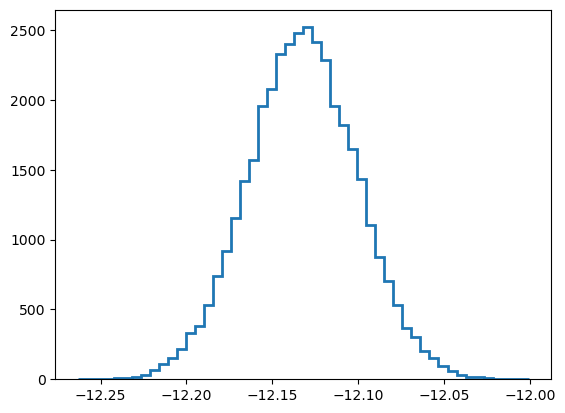

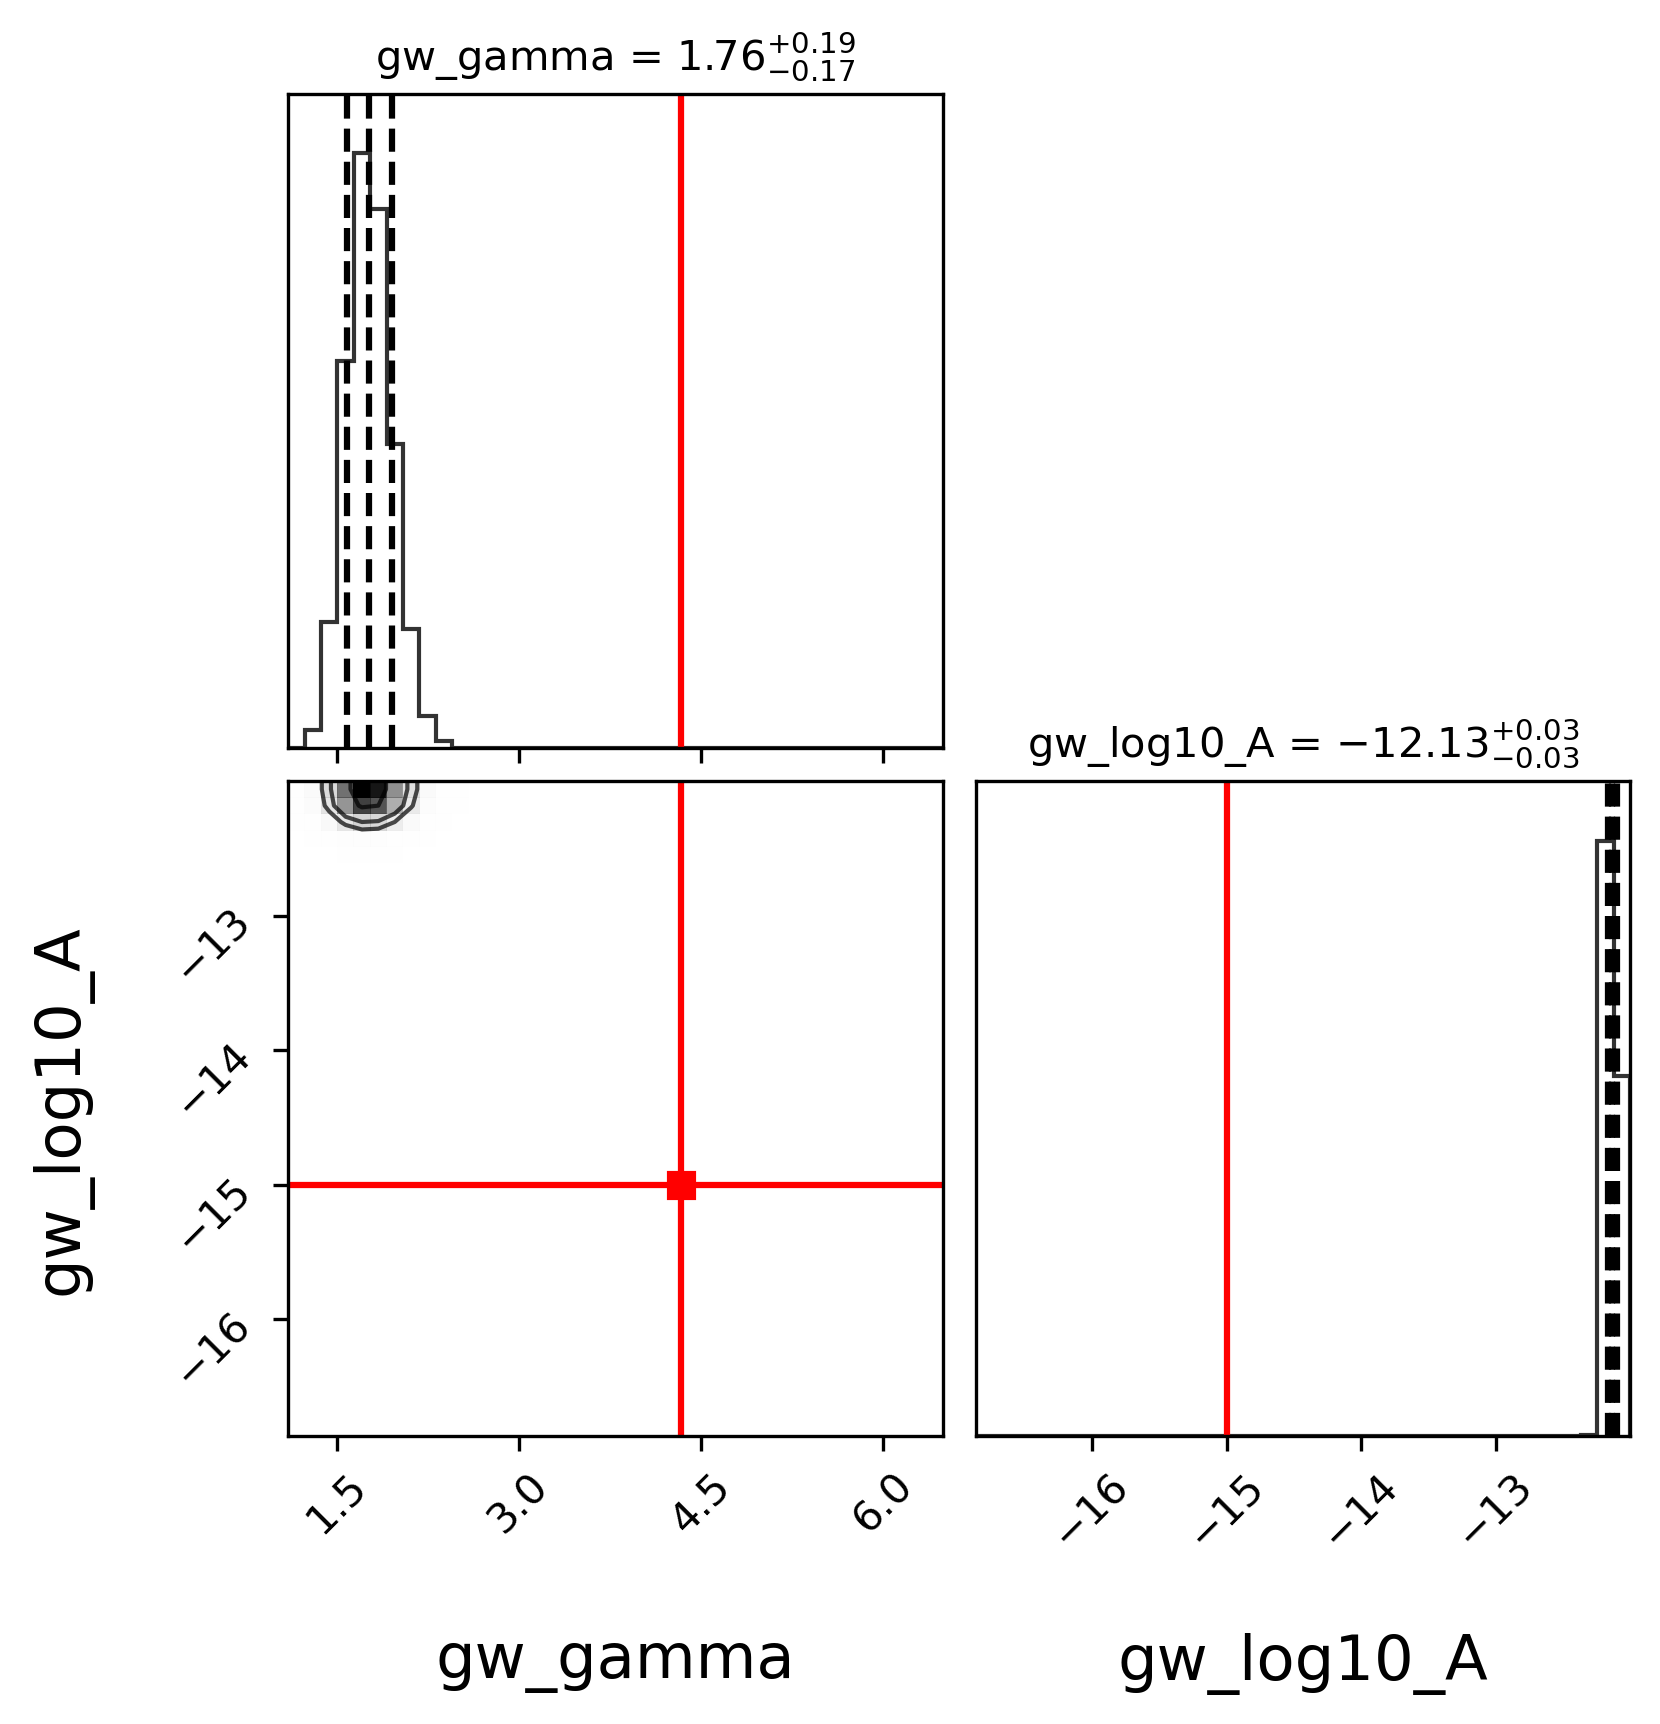

In [46]:
chain = np.loadtxt(outDir +'/chain_1.txt')
chain.shape
burn = int(0.25 * chain.shape[0])
samples = chain[:, :ndim]
plt.hist(chain[burn:,-5], 50, histtype='step', lw=2);

labels = pta.param_names

if labels[0] == 'gw_gamma':
    truths = [13./3., -15.0]
else:
    truths = [-15.0, 13./3.]

chain.shape

fig = plt.figure(figsize=(6, 6), dpi=300)

figure = corner.corner(
    samples,
    plot_datapoints=False,
    truths=truths,
    labels=labels,
    truth_color='red',
    bins=40,
    smooth=1.0,
    plot_density=True,
    fill_contours=False,
    contour_kwargs={"linewidths": 1.0, "alpha": 0.7},
    hist_kwargs={"density": True, "alpha": 0.8},
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 15},
    fig=fig
    )